# Ch 12 — 아이리스 품종 예측 (다중분류)

원본: `03_Iris_Multi_Classfication.py`

다루는 내용:
1. CSV 로드 + 컬럼 이름
2. seaborn pairplot으로 클래스 분리도 시각화
3. LabelEncoder + one-hot
4. Dense(16) → Dense(3, softmax)
5. categorical_crossentropy 손실

## 0. 환경

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import Input, Sequential
from keras.layers import Dense

keras.utils.set_random_seed(0)

print("Keras:", keras.__version__)

import seaborn as sns
from sklearn.preprocessing import LabelEncoder

2026-05-12 16:07:57.333204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778569677.351708 1497229 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778569677.357244 1497229 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.14.1


## 1. 데이터

In [2]:
DATA = "../../data/iris.csv"
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
df = pd.read_csv(DATA, names=columns)
print("shape:", df.shape)
print("classes:", df["species"].unique())
df.head()

shape: (150, 5)
classes: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. pairplot — 클래스 분리도

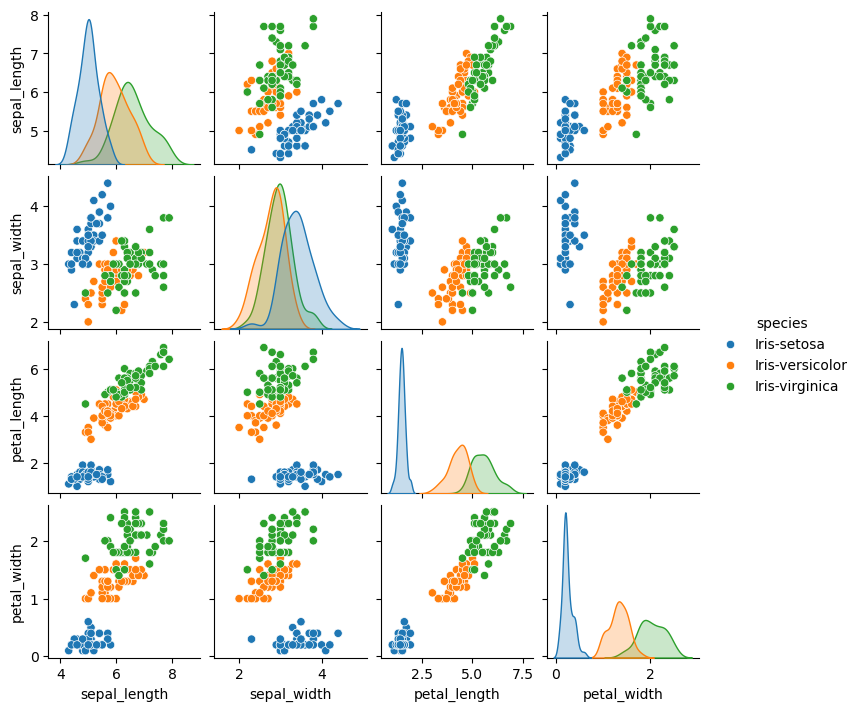

In [3]:
sns.pairplot(df, hue="species", height=1.8)
plt.show()

**관찰:** `setosa` 는 `petal_length`/`petal_width` 만으로도 거의 완벽하게 분리됨.
나머지 두 종은 일부 겹침이 있어 모델의 학습 대상은 사실상 그 두 종 구분.

## 3. 라벨 인코딩 + 원-핫

In [4]:
X = df.iloc[:, 0:4].to_numpy(dtype="float32")
y_str = df["species"].to_numpy()

encoder = LabelEncoder()
y_int = encoder.fit_transform(y_str)
print("classes (LabelEncoder):", list(encoder.classes_))
print("y_int 처음 5개:", y_int[:5])

y_onehot = keras.utils.to_categorical(y_int, num_classes=3)
print("y_onehot shape:", y_onehot.shape)
print("y_onehot 처음 3행:\n", y_onehot[:3])

classes (LabelEncoder): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
y_int 처음 5개: [0 0 0 0 0]
y_onehot shape: (150, 3)
y_onehot 처음 3행:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


## 4. 모델 — softmax 출력

In [5]:
keras.utils.set_random_seed(0)
model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax"),
])
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

2026-05-12 16:08:01.103193: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. 학습

In [6]:
hist = model.fit(X, y_onehot, epochs=50, batch_size=1, verbose=0)
print(f"final train accuracy: {hist.history['accuracy'][-1]:.4f}")

final train accuracy: 0.9733


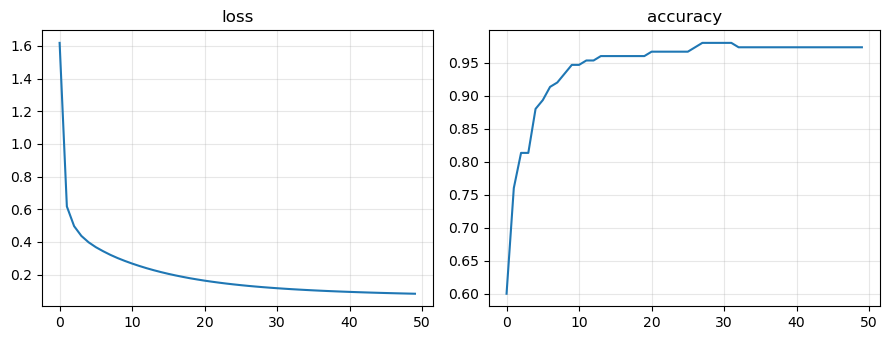

In [7]:
plt.figure(figsize=(9, 3.5))
plt.subplot(1, 2, 1); plt.plot(hist.history["loss"]); plt.title("loss"); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2); plt.plot(hist.history["accuracy"]); plt.title("accuracy"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 예측 디코딩

In [8]:
probs = model.predict(X[:5], verbose=0)
preds = np.argmax(probs, axis=1)
print("확률 (5개 × 3 클래스):\n", probs.round(3))
print("예측 정수:", preds)
print("예측 라벨:", encoder.inverse_transform(preds))
print("정답 라벨:", y_str[:5])

확률 (5개 × 3 클래스):
 [[1.    0.    0.   ]
 [0.999 0.001 0.   ]
 [1.    0.    0.   ]
 [0.999 0.001 0.   ]
 [1.    0.    0.   ]]
예측 정수: [0 0 0 0 0]
예측 라벨: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
정답 라벨: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']


## 마무리
- [ ] sparse_categorical_crossentropy 로 바꾸면 원-핫 없이도 학습 가능 (라벨이 정수면 됨)
- [ ] hidden layer를 빼면 (Linear → Softmax) 정확도가 어떻게 변하는지
- [ ] `batch_size=1` 의 효과 — SGD에 가까워서 학습이 매우 느리지만 변동이 큼